In [5]:
from sqlalchemy import create_engine, text

# Fix prefix if needed
db_url = db_url.replace("postgres://", "postgresql://", 1)

# Ensure SSL (Render requirement)
if "sslmode=" not in db_url:
    db_url += ("&" if "?" in db_url else "?") + "sslmode=require"

engine = create_engine(db_url, pool_pre_ping=True)

with engine.connect() as conn:
    print(conn.execute(text("SELECT 1")).fetchone())

print("✅ Engine ready")

(1,)
✅ Engine ready


In [6]:
import pandas as pd

df = pd.read_sql("""
SELECT
    r.review_text,
    r.rating,
    r.helpful_votes,
    r.verified_purchase,
    r.label
FROM review r
""", engine)

df.head()


,review_text,rating,helpful_votes,verified_purchase,label
0,This spray is really nice. It smells really go...,5,0,True,1
1,"This product does what I need it to do, I just...",4,1,True,1
2,"Smells good, feels great!",5,2,True,1
3,Felt synthetic,1,0,True,0
4,Love it,5,0,True,1


In [7]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49877 entries, 0 to 49876
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   review_text        49877 non-null  object
 1   rating             49877 non-null  int64 
 2   helpful_votes      49877 non-null  int64 
 3   verified_purchase  49877 non-null  bool  
 4   label              49877 non-null  int64 
dtypes: bool(1), int64(3), object(1)
memory usage: 1.6+ MB


In [8]:
df["label"].value_counts(normalize=True)


label
1    0.740842
0    0.259158
Name: proportion, dtype: float64

In [9]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["label"])
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train label distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest label distribution:")
print(y_test.value_counts(normalize=True)
)


Train label distribution:
label
1    0.740834
0    0.259166
Name: proportion, dtype: float64

Test label distribution:
label
1    0.740878
0    0.259122
Name: proportion, dtype: float64


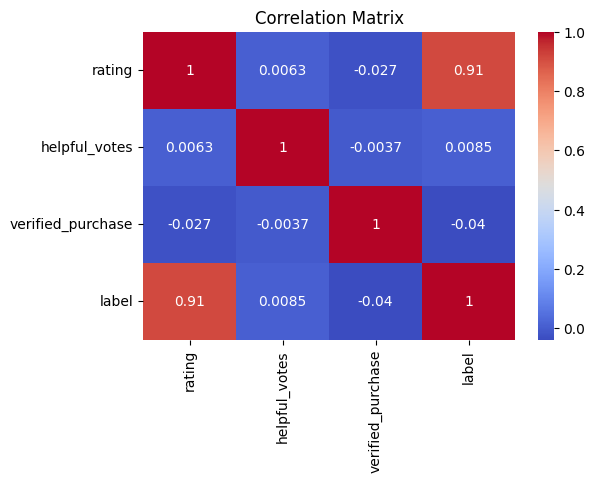

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df[["rating", "helpful_votes", "verified_purchase", "label"]].corr()

plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()


In [15]:
df.describe(include="all")


,review_text,rating,helpful_votes,verified_purchase,label
count,49877,49877.000000,49877.000000,49877,49877.000000
unique,47810,NaN,NaN,2,NaN
top,Love it,NaN,NaN,True,NaN
freq,102,NaN,NaN,42701,NaN
mean,NaN,4.070213,0.958257,NaN,0.740842
std,NaN,1.376015,5.138410,NaN,0.438177
min,NaN,1.000000,0.000000,NaN,0.000000
25%,NaN,3.000000,0.000000,NaN,0.000000
50%,NaN,5.000000,0.000000,NaN,1.000000
75%,NaN,5.000000,1.000000,NaN,1.000000


<Axes: title={'center': 'Label Distribution'}, xlabel='label'>

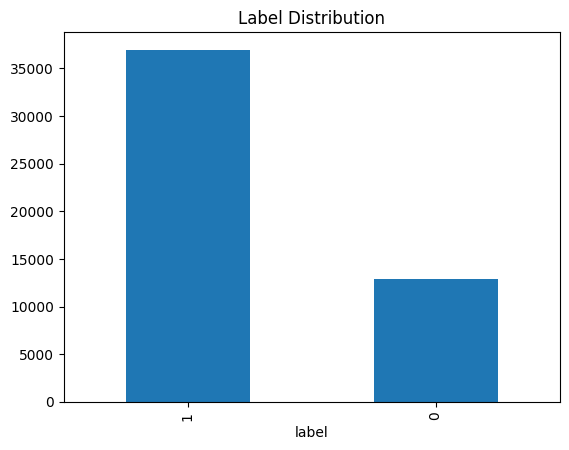

In [16]:
df["label"].value_counts().plot(kind="bar", title="Label Distribution")


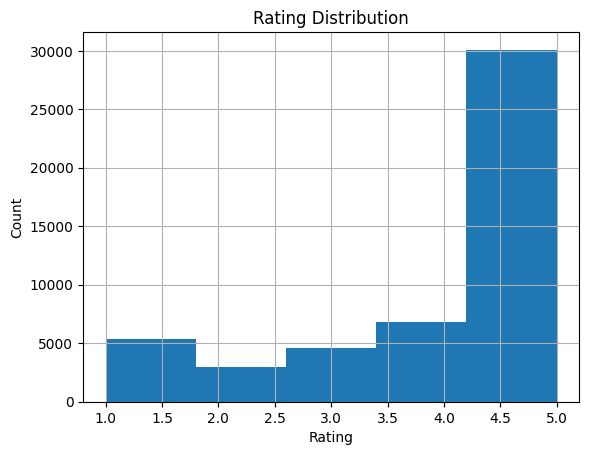

In [17]:
import matplotlib.pyplot as plt

df["rating"].hist(bins=5)
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()


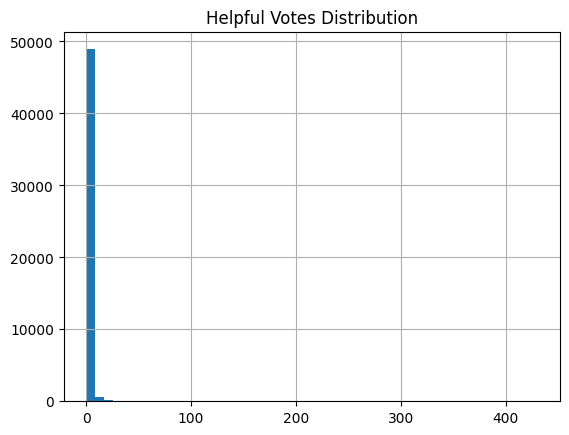

In [18]:
df["helpful_votes"].hist(bins=50)
plt.title("Helpful Votes Distribution")
plt.show()


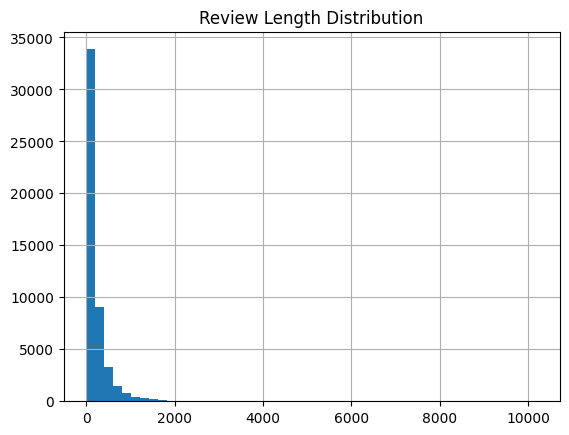

In [19]:
df["review_length"] = df["review_text"].str.len()
df["review_length"].hist(bins=50)
plt.title("Review Length Distribution")
plt.show()
